<a href="https://colab.research.google.com/github/ashishkhetwal/Medical-Insurance-Cost-Prediction/blob/main/Medical_Insurance_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [167]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


In [168]:
insurance_data = pd.read_csv('/content/insurance 2.csv')
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [169]:
insurance_data.shape

(1338, 7)

In [170]:
insurance_data.isnull().sum().sum()

np.int64(0)

#Categorical Values

 ->Sex

 ->Smoker

 ->Region

In [171]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_4834/1462066110.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_data['age'])


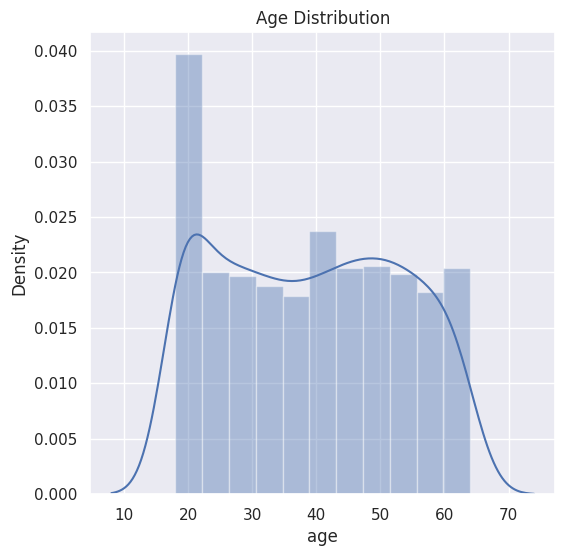

In [172]:
#distribution of age
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_data['age'])
plt.title('Age Distribution')
plt.show()

label encoding

Female -> 0
Male -> 1

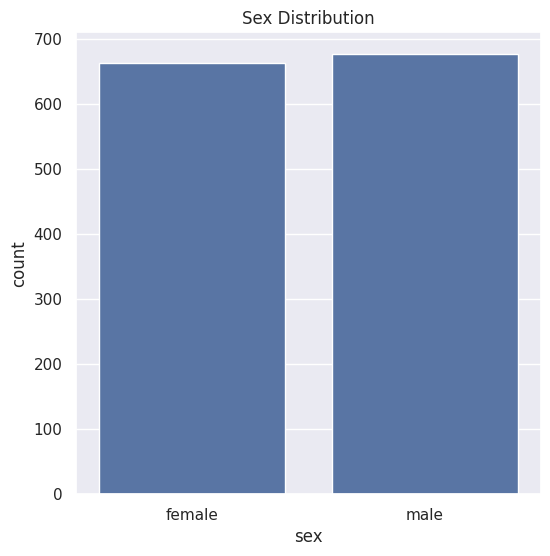

In [173]:
sns.set_theme()
plt.figure(figsize = (6,6))
sns.countplot(x = 'sex', data = insurance_data)
plt.title('Sex Distribution')
plt.show()

/tmp/ipykernel_4834/2235840663.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_data['bmi'])


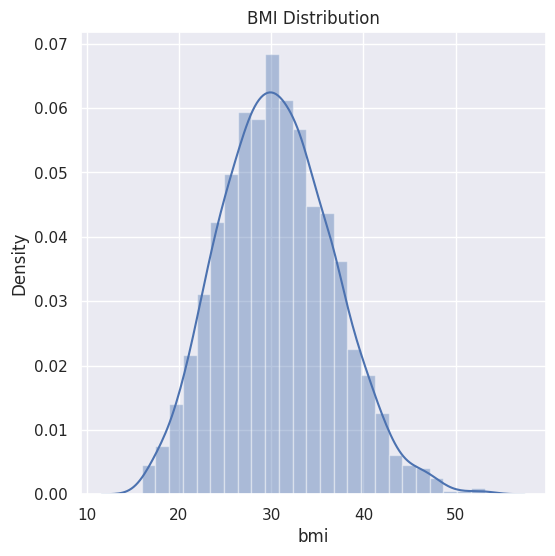

In [174]:
#distribution of age
sns.set_theme()
plt.figure(figsize=(6,6))
sns.distplot(insurance_data['bmi'])
plt.title('BMI Distribution')
plt.show()

Normal Range : 18.5 -> 25

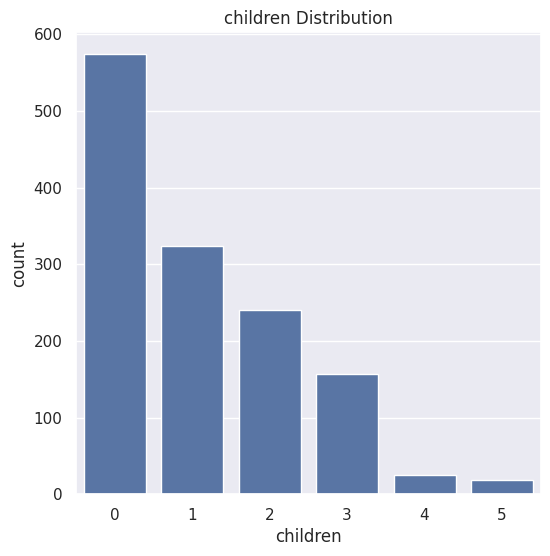

In [175]:

plt.figure(figsize = (6,6))
sns.countplot(x = 'children', data = insurance_data)
plt.title('children Distribution')
plt.show()

Categorical data

Smoker

Sex

Region

In [176]:
#converting the categorical data to numerical values
insurance_data.replace({'sex':{'male':0,'female':1}}, inplace=True)
insurance_data.replace({'smoker':{'yes':0,'no':1}}, inplace=True)
insurance_data.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}}, inplace=True)

/tmp/ipykernel_4834/2860588310.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_data.replace({'sex':{'male':0,'female':1}}, inplace=True)
/tmp/ipykernel_4834/2860588310.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_data.replace({'smoker':{'yes':0,'no':1}}, inplace=True)
/tmp/ipykernel_4834/2860588310.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to th

In [177]:
insurance_data['sex'].value_counts()

,count
sex,
0,676
1,662


In [178]:
X = insurance_data.drop(columns = 'charges', axis = 1)
Y = insurance_data['charges']

In [179]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,0,1
1,18,0,33.770,1,1,0
2,28,0,33.000,3,1,0
3,33,0,22.705,0,1,3
4,32,0,28.880,0,1,3


In [180]:
Y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [181]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [182]:
X_train.shape

(1070, 6)

In [183]:
X_test.shape

(268, 6)

In [184]:
Y_test.head()

,charges
17,2395.17155
1091,11286.53870
273,9617.66245
270,1719.43630
874,8891.13950


In [185]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [186]:
X_train_prediction = model.predict(X_train)

In [187]:
r2_error = r2_score(Y_train, X_train_prediction)
print('r2 error = ', r2_error)
mse = mean_squared_error(Y_train, X_train_prediction)
print('mse = ', mse)
mae = mean_absolute_error(Y_train, X_train_prediction)
print('mae = ', mae)

r2 error =  0.751505643411174
mse =  36174978.427092075
mae =  4150.500304883777


In [188]:
#Making a predictive system
def predict_cost(input_data):
  input_data_as_numpy_array = np.asarray(input_data)
  input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
  prediction = model.predict(input_data_reshaped)
  return prediction[0]


In [197]:
row = X_test.iloc[1].values
print("Input:", row)
print("Actual:", Y_test.iloc[1])
print("Predicted:", predict_cost(row))

Input: [55.    1.   29.83  0.    1.    2.  ]
Actual: 11286.5387
Predicted: 11570.592017797966


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
